In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 

In [4]:
df= pd.read_csv("Raw_superstore_dataset.csv")
df

,Transaction_ID,Transaction_Date,Transaction_Month,Customer_ID,Customer_Segment,Region,Product_Category,Quantity,Discount_Percentage,Actual_Billed_Amount
0,TXN_1,12-07-2023,Jul,CUST_1,Consumer,South,Technology,8,0.19,997.92
1,TXN_2,03-11-2023,Nov,CUST_2,Corporate,West,Furniture,4,0.24,777.16
2,TXN_3,30-06-2023,Jun,CUST_3,Consumer,West,Technology,9,0.27,736.28
3,TXN_4,19-10-2023,Oct,CUST_4,Corporate,South,Technology,5,0.19,800.71
4,TXN_5,09-10-2023,Oct,CUST_5,Corporate,Central,Furniture,9,0.29,228.82
...,...,...,...,...,...,...,...,...,...,...
195,TXN_196,03-08-2023,Aug,CUST_196,Corporate,Central,Office Supplies,9,0.05,463.94
196,TXN_197,26-06-2023,Jun,CUST_197,Corporate,South,Technology,1,0.26,793.82
197,TXN_198,09-01-2023,Jan,CUST_198,Home Office,West,Technology,7,0.15,479.83
198,TXN_199,09-04-2023,Apr,CUST_199,Home Office,East,Office Supplies,5,0.22,418.48


In [6]:
df.shape

(200, 10)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Transaction_ID        200 non-null    object 
 1   Transaction_Date      200 non-null    object 
 2   Transaction_Month     200 non-null    object 
 3   Customer_ID           200 non-null    object 
 4   Customer_Segment      200 non-null    object 
 5   Region                200 non-null    object 
 6   Product_Category      200 non-null    object 
 7   Quantity              200 non-null    int64  
 8   Discount_Percentage   200 non-null    float64
 9   Actual_Billed_Amount  200 non-null    float64
dtypes: float64(2), int64(1), object(7)
memory usage: 15.8+ KB


In [8]:
df.describe()

,Quantity,Discount_Percentage,Actual_Billed_Amount
count,200.000000,200.000000,200.000000
mean,4.925000,0.155400,567.350850
std,2.614105,0.082504,244.548095
min,1.000000,0.000000,110.980000
25%,3.000000,0.100000,368.390000
50%,5.000000,0.160000,574.400000
75%,7.000000,0.220000,781.582500
max,9.000000,0.300000,997.920000


In [9]:
df.isnull().sum()      #check missing values

Transaction_ID          0
Transaction_Date        0
Transaction_Month       0
Customer_ID             0
Customer_Segment        0
Region                  0
Product_Category        0
Quantity                0
Discount_Percentage     0
Actual_Billed_Amount    0
dtype: int64

In [ ]:
df.duplicated().sum()   #check duplicate valuess

**Understand Categorical Values**

In [13]:

df['Region'].value_counts()


Region
West       58
South      52
East       50
Central    40
Name: count, dtype: int64

In [14]:
df['Product_Category'].value_counts()

Product_Category
Technology         73
Furniture          66
Office Supplies    61
Name: count, dtype: int64

In [15]:
df['Customer_Segment'].value_counts()

Customer_Segment
Consumer       69
Home Office    66
Corporate      65
Name: count, dtype: int64

**Revenue Overview**

In [17]:
df['Actual_Billed_Amount'].sum()

np.float64(113470.17)

**Distribution**

<function matplotlib.pyplot.show(close=None, block=None)>

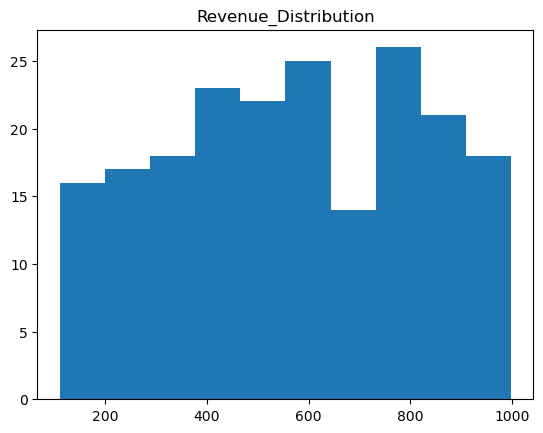

In [19]:
plt.hist(df['Actual_Billed_Amount'])
plt.title("Revenue_Distribution")
plt.show

**Insights**
- Central Tendency: The majority of revenues fall in the mid-range (likely between ~400–700). This is the “sweet spot” where most business activity happens.
- Revenue Extremes: High-value transactions (near 1000) are infrequent but could represent premium customers or bulk deals. Low-value transactions (near 100) are also rare, possibly entry-level purchases.
- Distribution Shape: The histogram suggests a bell-like curve, indicating a normal-ish distribution, but with possible slight skew depending on exact bar heights.


**Discount Analysis**

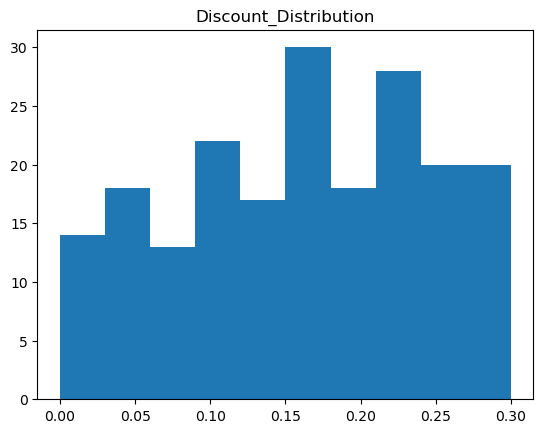

In [3]:
import matplotlib.pyplot as plt 
import pandas as pd 
df=pd.read_csv("Raw_superstore_dataset.csv")
plt.hist(df['Discount_Percentage'])
plt.title("Discount_Distribution")
plt.show()

**Revenue by Region**

<function matplotlib.pyplot.show(close=None, block=None)>

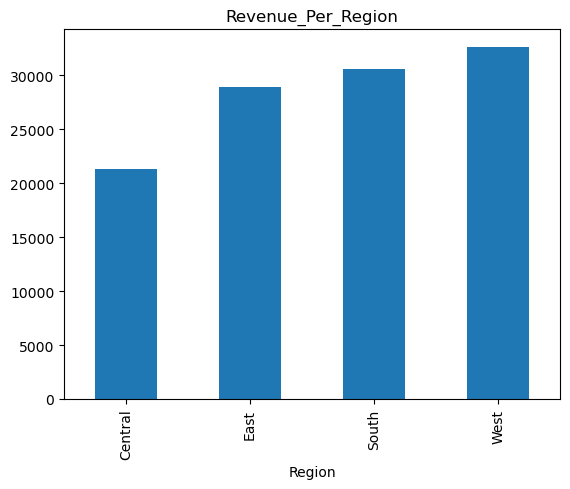

In [7]:
df.groupby("Region")["Actual_Billed_Amount"].sum().plot(kind='bar')
plt.title('Revenue_Per_Region')
plt.show

**Insights**
- West (~33,000): The strongest region, leading overall revenue performance.
- South (~30,500): Solid second, close to the West, showing strong demand.
- East (~29,000): Competitive but slightly behind South, still a major contributor.
- Central (~21,500): Noticeably weaker, trailing by a wide margin compared to other regions.


**Revenue by Category**

<function matplotlib.pyplot.show(close=None, block=None)>

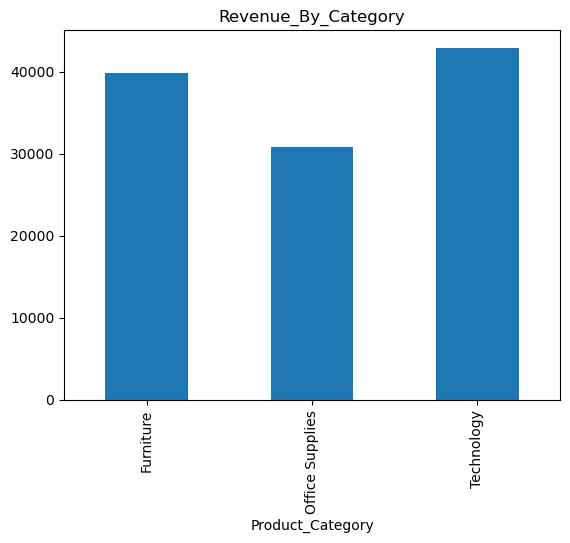

In [9]:
df.groupby('Product_Category')['Actual_Billed_Amount'].sum().plot(kind='bar')
plt.title('Revenue_By_Category')
plt.show

**Insights**
- Technology (~43,000): The strongest performer, slightly ahead of Furniture. This suggests high demand and possibly higher margins or faster turnover.
- Furniture (~40,000): Close second, showing strong contribution but slightly behind Technology.
- Office Supplies (~31,000): Noticeably lower compared to the other two categories, indicating either lower demand, lower pricing, or limited growth potential.


**Time Based Analysis**

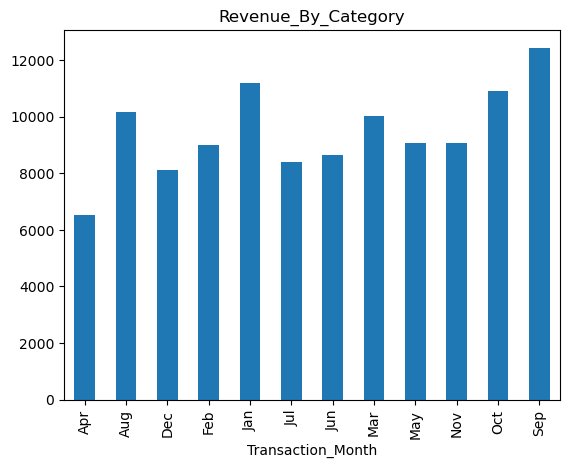

In [14]:

df.groupby('Transaction_Month')['Actual_Billed_Amount'].sum().plot(kind='bar')
plt.title('Revenue_By_Category')
plt.show()

**Insights**

- Seasonality: Clear spike in September, followed by sustained strong performance through October–December. This could align with festive seasons, promotional campaigns, or industry-specific cycles.
- Growth Opportunity: April and early months (Feb–Mar) consistently underperform. These months may benefit from targeted campaigns or product launches to smooth revenue distribution.



**Average Order Value**

In [4]:
import pandas as pd
df= pd.read_csv("Raw_superstore_dataset.csv")
df['Actual_Billed_Amount'].mean()

np.float64(567.35085)

**Revenue By Customer Segment**

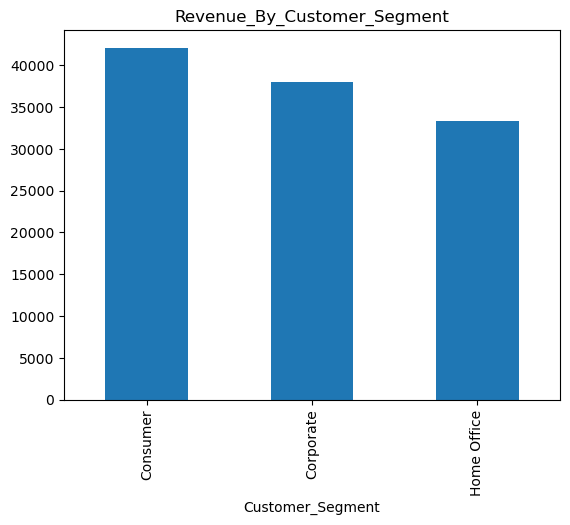

In [6]:
import matplotlib.pyplot as plt 
df.groupby('Customer_Segment')['Actual_Billed_Amount'].sum().plot(kind='bar')
plt.title("Revenue_By_Customer_Segment")
plt.show()

**Insights**
- Consumer (~42,000): The largest contributor, clearly leading overall revenue.
- Corporate (~38,000): Strong second, not far behind Consumer.
- Home Office (~33,000): The lowest segment, trailing by ~9,000 compared to Consumer.


**Quantity vs Revenue**

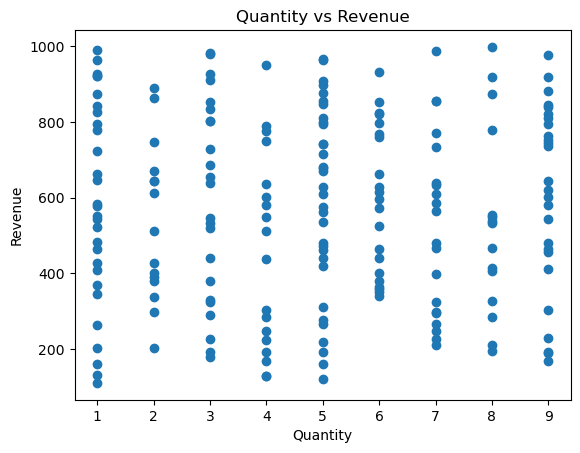

In [8]:
plt.scatter(df['Quantity'],df['Actual_Billed_Amount'])
plt.title("Quantity vs Revenue")
plt.xlabel("Quantity")
plt.ylabel("Revenue")
plt.show()

**Insights**
- Non-linear Relationship: Revenue doesn’t scale evenly with quantity. Some small orders generate high revenue, while some large orders remain low-value.
- High-Value Drivers: Premium products or categories likely explain high revenue at low quantities.
- Bulk Sales Impact: Larger quantities tend to push revenue higher overall, but variability means not all bulk sales are equally profitable


**Quantity vs Revenue**

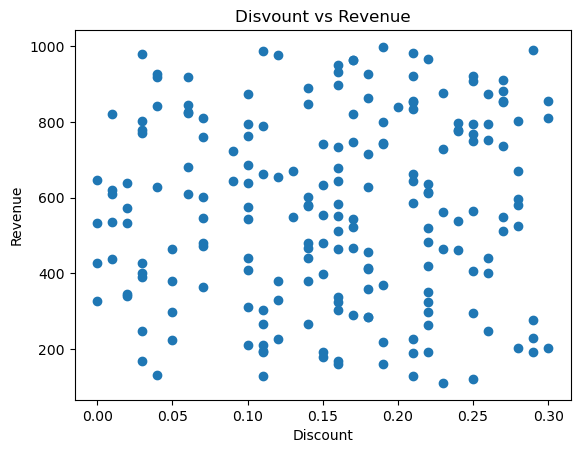

In [10]:
plt.scatter(df['Discount_Percentage'],df['Actual_Billed_Amount'])
plt.title("Disvount vs Revenue")
plt.xlabel("Discount")
plt.ylabel("Revenue")
plt.show()

**Insights**
- Weak Correlation: Discounts don’t strongly predict revenue. High revenue occurs even at low or zero discounts, meaning product value or demand plays a bigger role.
- Profit Risk: Larger discounts don’t guarantee higher revenue and may reduce margins.
- Outliers: Some transactions achieve high revenue with minimal discount—these are premium sales or strong brand-driven purchases.


**Top 10 customers By Revenue**

**Category vs Discount**

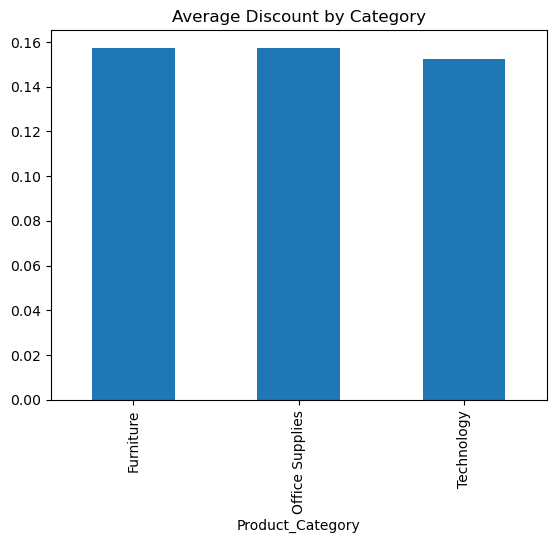

In [12]:
df.groupby('Product_Category')['Discount_Percentage'].mean().plot(kind='bar')
plt.title("Average Discount by Category")
plt.show()

**Insights**
- Discount Reliance: Furniture and Office Supplies depend more on discounts to sustain sales, which may erode margins.
- Technology Strength: Technology maintains high revenue (from earlier charts) with lower average discounts, showing strong pricing power and customer willingness to pay.
- Margin Pressure: Heavy discounting in Furniture and Office Supplies could explain why these categories lag behind Technology in profitability despite strong revenue contributions.


**Monthly Transaction Count**

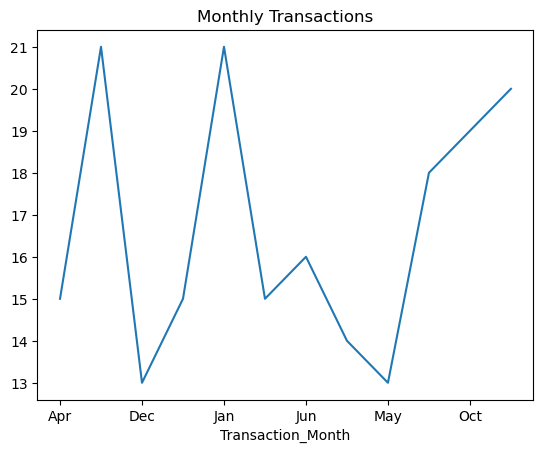

In [14]:
df['Transaction_Month'].value_counts().sort_index().plot()
plt.title("Monthly Transactions")
plt.show()

**Insights**
- Seasonal Surge: December–January likely benefit from holiday demand, fiscal year-end purchases, or corporate budget resets.
- Mid-Year Slowdown: May–June consistently underperform, possibly due to off-season demand or reduced corporate spending cycles.
- Transaction vs Revenue: Comparing this with earlier Revenue by Month chart, it’s possible that high revenue months (like September) don’t always align with high transaction counts-indicating fewer but higher-value transactions.


**Boxplot**

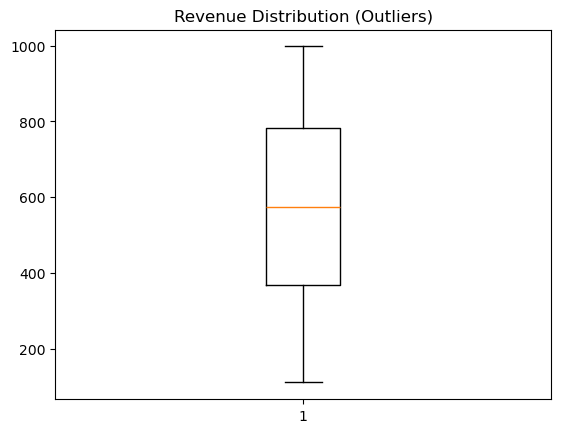

In [16]:
plt.boxplot(df['Actual_Billed_Amount'])
plt.title("Revenue Distribution (Outliers)")
plt.show()

**Insights**
- Revenue Spread: Transactions vary widely, from ~120 to ~1000, showing diverse customer/product behaviors.
- Skewness: The median is closer to the lower quartile, suggesting a slight skew toward higher-value transactions.
- High-Value Outliers: Transactions near 1000 are rare but significant—these likely represent premium sales or bulk deals.
- Low-Value Outliers: Transactions near 120 may be low-margin, potentially costly if frequent.
